# F3NinaG — Compostos de SSTA: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaG`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook descreve a diversidade interna dos eventos de La Niña, separando magnitude, duração e forma da trajetória. Classes de intensidade são comparadas somente dentro do mesmo sinal para não transformar assimetria El Niño–La Niña em diferença de classe.

## 2. Pergunta científica

Como intensidade e duração diferem entre classes do mesmo sinal?

## 3. Hipótese específica

Eventos mais intensos de La Niña apresentam trajetórias de SSTA/ONI, duração e amplitude sistematicamente diferentes, embora localização e evolução espacial possam variar entre eventos da mesma classe.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

Os compostos são calculados por evento e por classe definida pela magnitude absoluta do pico, preservando a polaridade original. Resumos entre eventos, e não todas as semanas agrupadas, sustentam a comparação.

## 5. Metodologia

Compostos por evento e classe baseada na magnitude absoluta do pico, mantendo o sinal físico original.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- compostos de SSTA/ONI por classe de intensidade.
- distribuições de duração, taxa de crescimento e magnitude.
- registro da variabilidade entre eventos dentro de cada classe.

- figuras públicas iniciadas por `FigF3NinaG`;
- tabelas públicas iniciadas por `TabF3NinaG`;
- primeiro par reservado: `FigF3NinaG1` ↔ `TabF3NinaG1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Timmermann, A. et al. (2018). El Niño–Southern Oscillation complexity. Nature, 559, 535–545.
2. Trenberth, K. E. (1997). The Definition of El Niño. Bulletin of the American Meteorological Society, 78, 2771–2777.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaG'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaG",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaG',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,composto SSTA por classe,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,57783


## Resultados

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaG,1,fase3_nina,FigF3NinaG1_composto_ssta_classe,TabF3NinaG1_composto_ssta_classe,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,71e11dc5639dfa1f7f64a270429d3826b6f22ec2667a39...,237cc64f9b27fdb62d96349be12a164c6b02f1fd9aa9f4...,20260714T202702Z_5538a635


,tipo,classe,semana_rel_pico,ssta_media_c,ssta_dp_c,n_eventos,alinhamento
0,la_nina,forte,-52,-1.396281,NaN,1,semana 0 = semana mais proxima do pico ONI do ...
1,la_nina,forte,-51,-1.502004,NaN,1,semana 0 = semana mais proxima do pico ONI do ...
2,la_nina,forte,-50,-1.799379,NaN,1,semana 0 = semana mais proxima do pico ONI do ...
3,la_nina,forte,-49,-1.813285,NaN,1,semana 0 = semana mais proxima do pico ONI do ...
4,la_nina,forte,-48,-1.889482,NaN,1,semana 0 = semana mais proxima do pico ONI do ...
...,...,...,...,...,...,...,...
195,la_nina,fraco,38,-0.122282,0.550490,4,semana 0 = semana mais proxima do pico ONI do ...
196,la_nina,fraco,39,-0.014200,0.524263,4,semana 0 = semana mais proxima do pico ONI do ...
197,la_nina,fraco,40,-0.067483,0.631411,4,semana 0 = semana mais proxima do pico ONI do ...
198,la_nina,fraco,41,-0.006300,0.647665,4,semana 0 = semana mais proxima do pico ONI do ...


## Figuras para verificação rápida

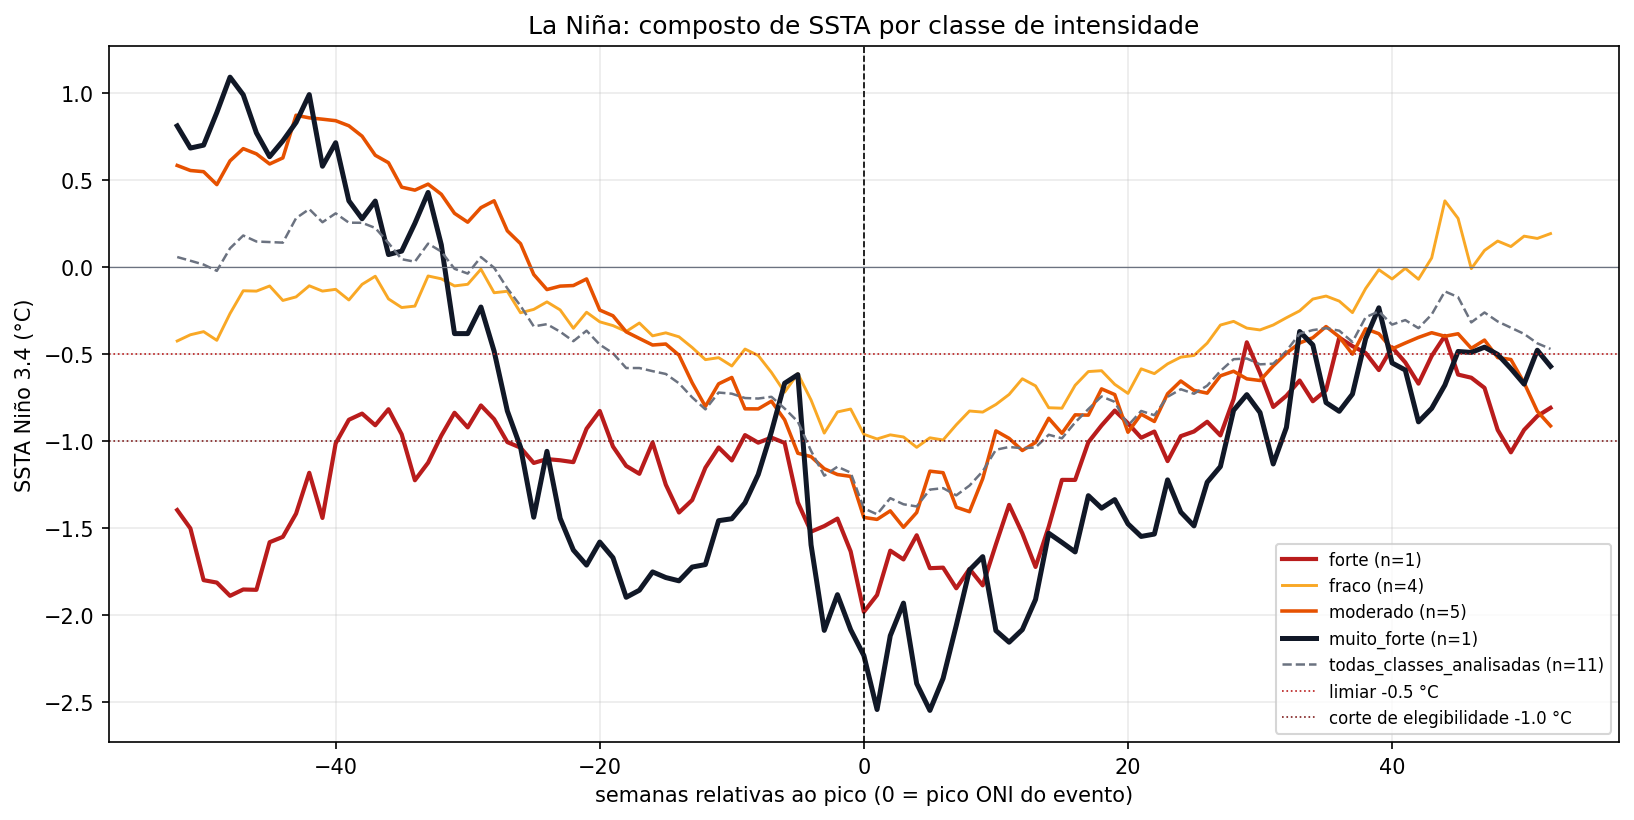

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- Compostos alinhados ao pico de cada evento; classes com pico ≥ 1 °C: forte (n=1), fraco (n=4), moderado (n=5), muito_forte (n=1).
- A curva média por classe descreve a trajetória típica; a dispersão entre eventos permanece na tabela.

Limitações:
- As figuras resumem tabelas auditadas; consulte tabela, manifesto e unidade antes de interpretar valores individuais.
- Leituras de propagação e influência são diagnósticas por evento; não há detector formal de onda nem atribuição causal.
- Somente eventos elegíveis do sinal isolado entram nos painéis; o número de eventos independentes acompanha cada tabela.
